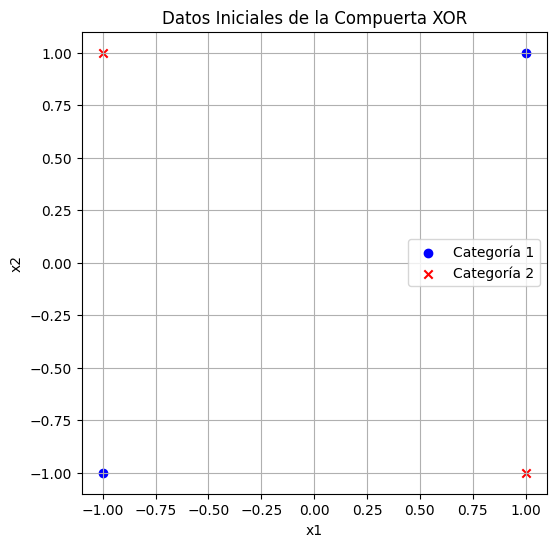

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.close('all')
 
# Paso 1: Definición de datos para la compuerta XOR
x_data = np.array([[-1, -1], [1, 1], [1, -1], [-1, 1]])
y_data = np.array([1, 1, -1, -1])
 
# Graficar los datos iniciales
plt.figure(figsize=(6, 6))
plt.scatter(x_data[:2, 0], x_data[:2, 1], color='blue', marker='o', label='Categoría 1')
plt.scatter(x_data[2:, 0], x_data[2:, 1], color='red', marker='x', label='Categoría 2')
plt.title('Datos Iniciales de la Compuerta XOR')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid()
plt.show()

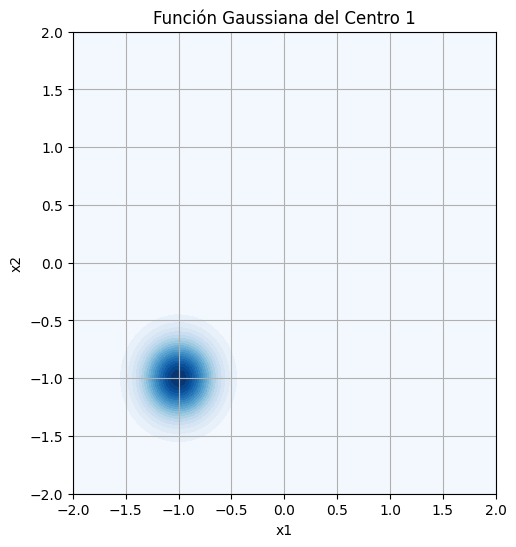

In [27]:
# Paso 2: Parámetros de la red
centers = np.array([[-1, -1], [1, 1]])  # Los centros de cada neurona de la capa RBF
spread = 10 # Parámetro que controla la amplitud de las funciones Gaussianas
 
# Graficar las funciones Gaussianas para cada centro
x_range = np.linspace(-2, 2, 100)
y_range = np.linspace(-2, 2, 100)
x_grid, y_grid = np.meshgrid(x_range, y_range)
z_grid_1 = np.zeros_like(x_grid, dtype=float)
z_grid_2 = np.zeros_like(x_grid, dtype=float)
 
for i in range(x_grid.shape[0]):
    for j in range(x_grid.shape[1]):
        z_grid_1[i, j] = np.exp(-spread * np.linalg.norm(np.array([x_grid[i, j], y_grid[i, j]]) - centers[0]) ** 2)
        z_grid_2[i, j] = np.exp(-spread * np.linalg.norm(np.array([x_grid[i, j], y_grid[i, j]]) - centers[1]) ** 2)
 
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.contourf(x_grid, y_grid, z_grid_1, levels=20, cmap='Blues')
plt.title('Función Gaussiana del Centro 1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

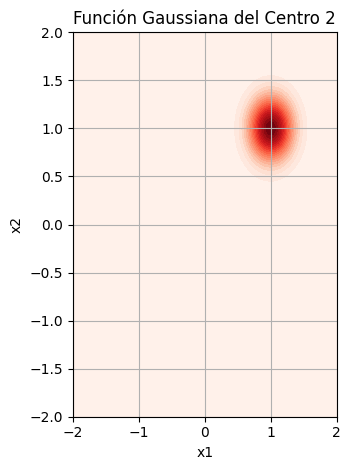

In [28]:
plt.subplot(1, 2, 2)
plt.contourf(x_grid, y_grid, z_grid_2, levels=20, cmap='Reds')
plt.title('Función Gaussiana del Centro 2')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()
 
plt.tight_layout()
plt.show()

In [29]:
# Paso 3: Calcular la salida de la capa RBF
rbf_outputs = np.zeros((len(x_data), len(centers)))
for i in range(len(x_data)):
    for j in range(len(centers)):
        rbf_outputs[i, j] = np.exp(-spread * np.linalg.norm(x_data[i] - centers[j]) ** 2)

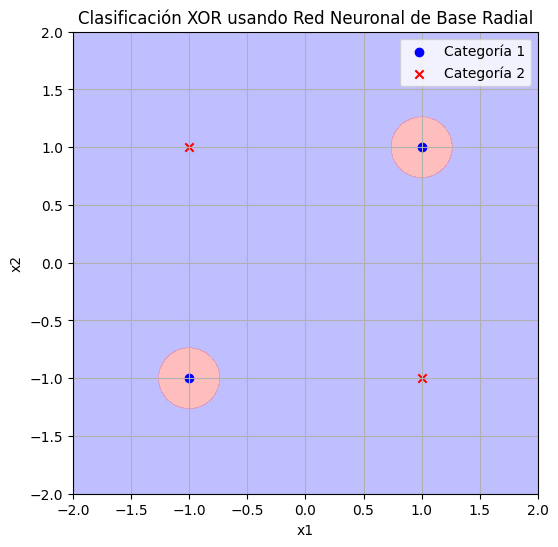

In [30]:
# Paso 4: Ajustar pesos de la capa de salida (Lineal)
rbf_outputs = np.hstack((rbf_outputs, np.ones((rbf_outputs.shape[0], 1))))  # Añadir bias
weights = np.linalg.pinv(rbf_outputs).dot(y_data)
 
# Paso 5: Graficar la red y los resultados
z_grid = np.zeros_like(x_grid, dtype=float)
 
for i in range(x_grid.shape[0]):
    for j in range(x_grid.shape[1]):
        rbf_layer = np.array([np.exp(-spread * np.linalg.norm(np.array([x_grid[i, j], y_grid[i, j]]) - center) ** 2) for center in centers])
        rbf_layer = np.append(rbf_layer, 1)  # Añadir bias
        z_grid[i, j] = np.dot(weights, rbf_layer)
 
plt.figure(figsize=(6, 6))
plt.contourf(x_grid, y_grid, z_grid, levels=[-1, 0, 1], alpha=0.5, cmap='bwr')
plt.scatter(x_data[:2, 0], x_data[:2, 1], color='blue', marker='o', label='Categoría 1')
plt.scatter(x_data[2:, 0], x_data[2:, 1], color='red', marker='x', label='Categoría 2')
plt.title('Clasificación XOR usando Red Neuronal de Base Radial')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid()
plt.show()